In [1]:
import os
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imutils', '-q'])

import random
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
import imutils
import PIL


## Path Configuration

In [2]:
train_dir = r"C:\Users\LENOVO\Downloads\research\Training" + "\\"
test_dir  = r"C:\Users\LENOVO\Downloads\research\Testing"  + "\\"
save_dir  = r"C:\Users\LENOVO\Downloads\research"          + "\\"

crop_train_dir = os.path.join(save_dir, "Crop-Brain-MRI")
crop_test_dir  = os.path.join(save_dir, "Test-Data")

for folder in ["glioma", "meningioma", "notumor", "pituitary"]:
    os.makedirs(os.path.join(crop_train_dir, folder), exist_ok=True)
    os.makedirs(os.path.join(crop_test_dir,  folder), exist_ok=True)


## Data Visualization

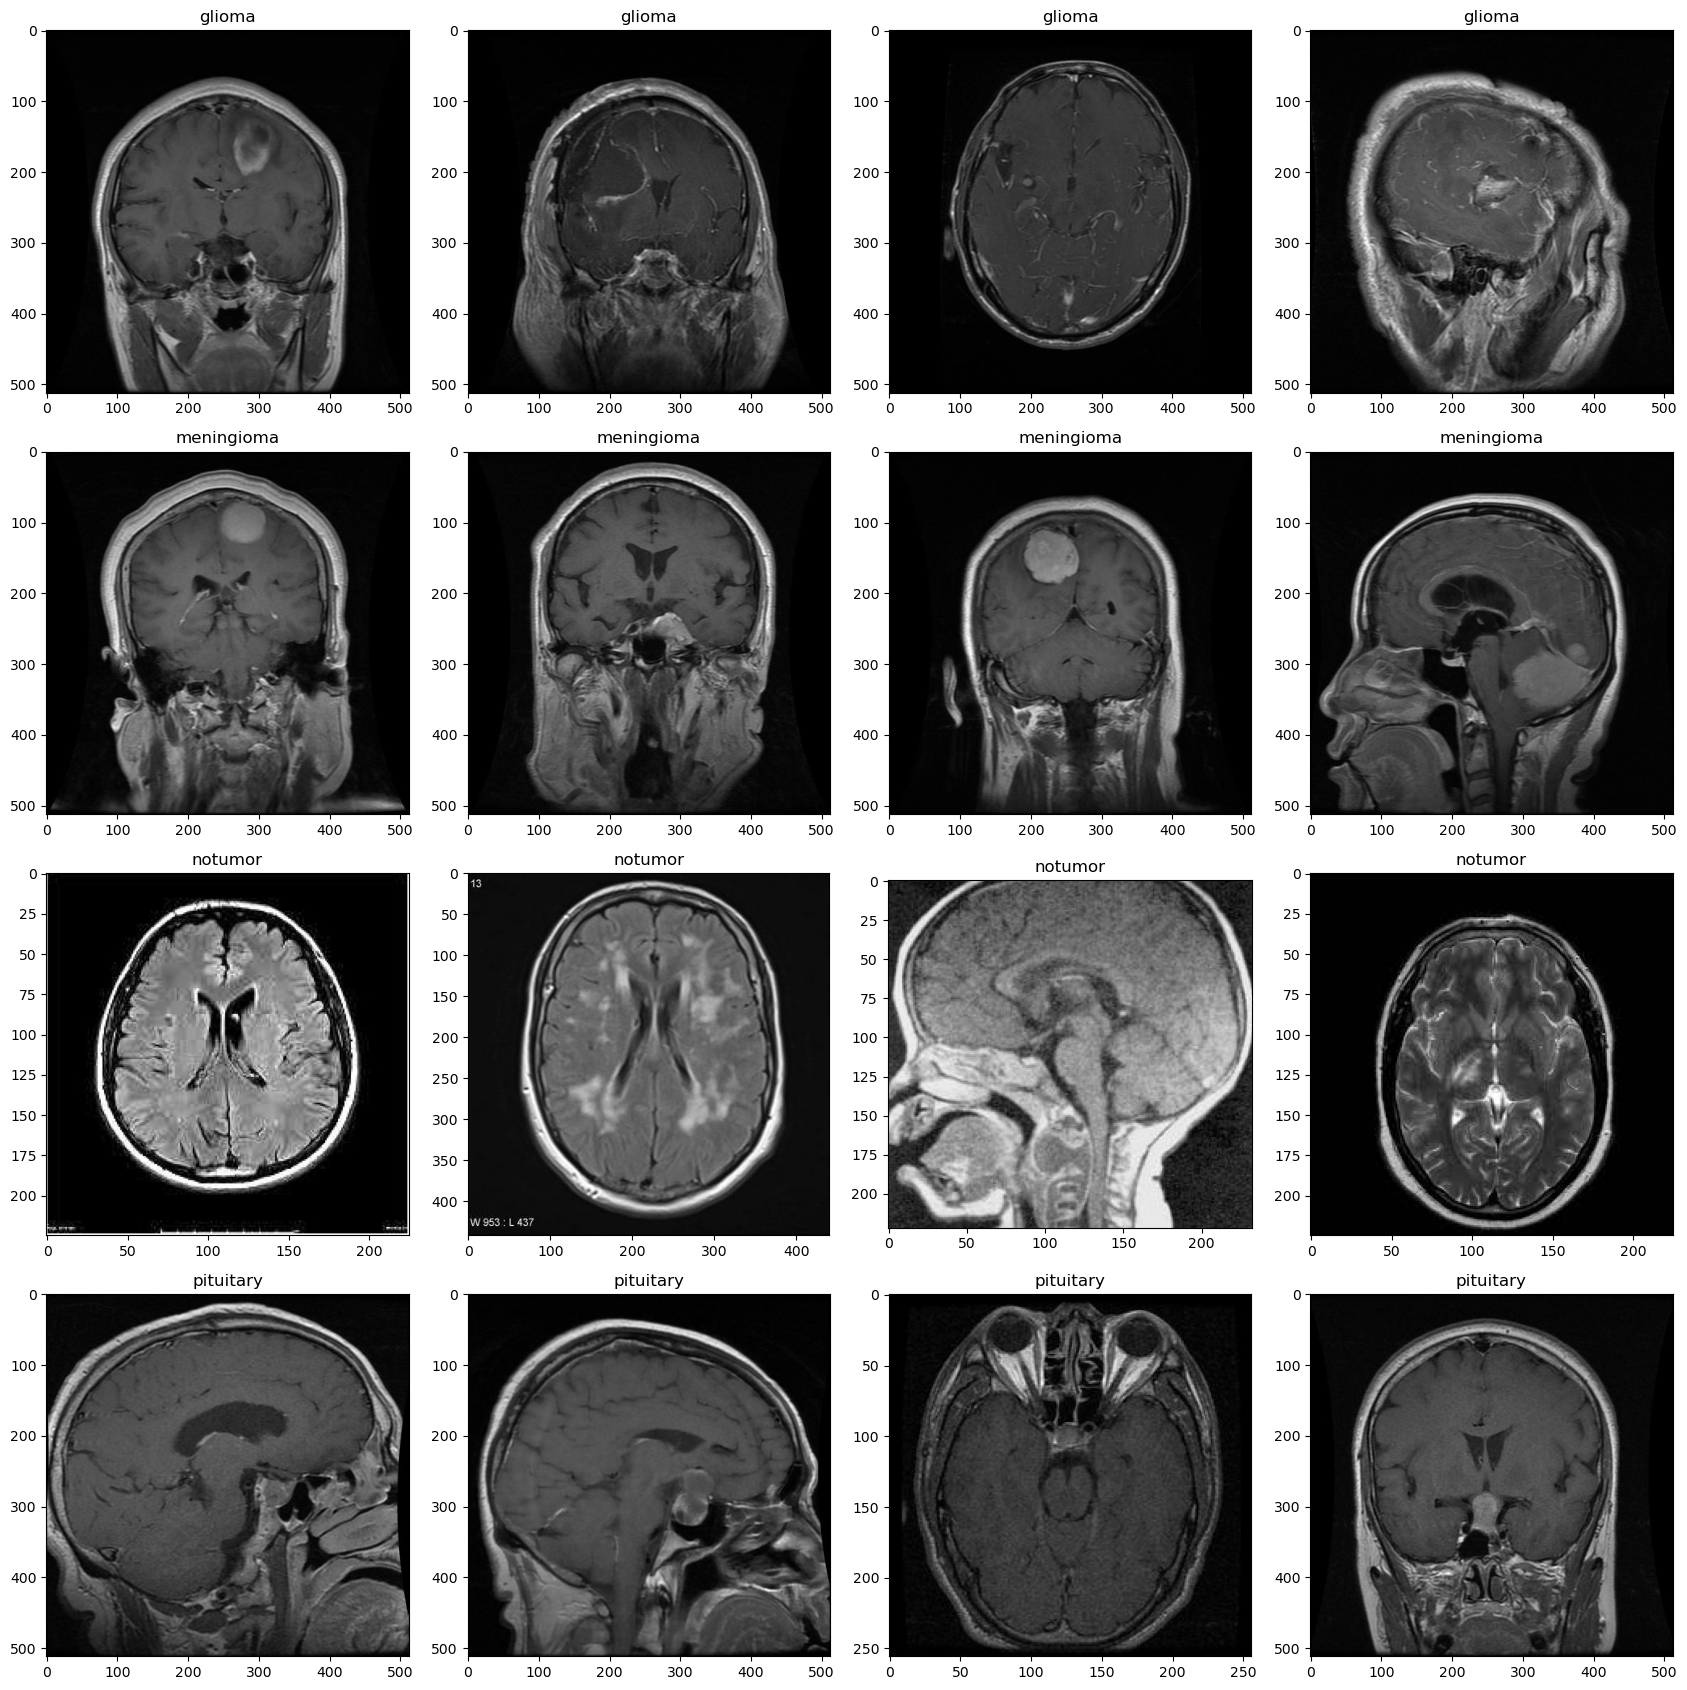

In [3]:
from tensorflow.keras.preprocessing.image import load_img

classes = os.listdir(train_dir)

filepath_dict = {}
for c in classes:
    filepath_dict[c] = [os.path.join(train_dir, c, x) for x in os.listdir(os.path.join(train_dir, c))]

plt.figure(figsize=(17, 17))
index = 0
for c in classes:
    random.shuffle(filepath_dict[c])
    path_list = filepath_dict[c][:5]
    for i in range(1, 5):
        index += 1
        plt.subplot(4, 4, index)
        plt.imshow(load_img(path_list[i]))
        plt.title(c)
plt.tight_layout()
plt.show()


Number of images in glioma : 1400
Number of images in meningioma : 1400
Number of images in notumor : 1400
Number of images in pituitary : 1400


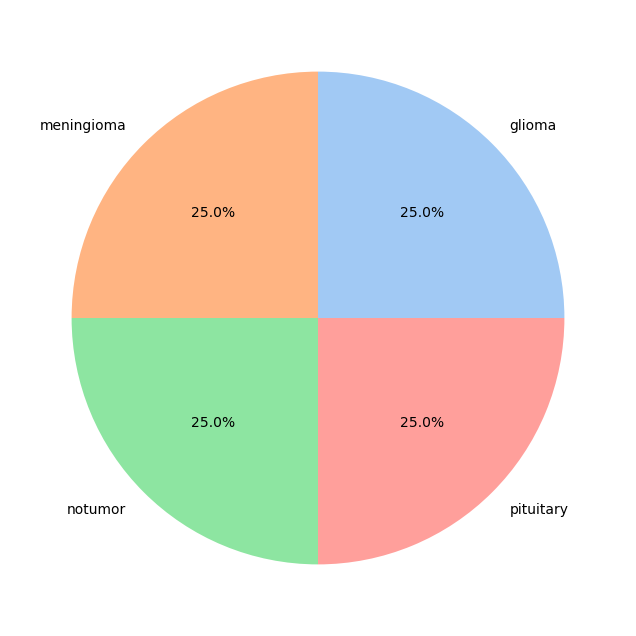

In [4]:
No_images_per_class = []
Class_name = []
for i in classes:
    train_class = os.listdir(os.path.join(train_dir, i))
    No_images_per_class.append(len(train_class))
    Class_name.append(i)
    print(f"Number of images in {i} : {len(train_class)}")

plt.figure(figsize=(8, 8))
colors = sns.color_palette("pastel")
plt.pie(No_images_per_class, labels=Class_name, autopct="%1.1f%%", colors=colors)
plt.show()


## Image Preprocessing - Crop Brain MRI

In [5]:
def crop_image(image, plot=False):
    img_gray   = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    img_blur   = cv2.GaussianBlur(img_gray, (5, 5), 0)
    img_thresh = cv2.threshold(img_blur, 45, 255, cv2.THRESH_BINARY)[1]
    img_thresh = cv2.erode(img_thresh, None, iterations=2)
    img_thresh = cv2.dilate(img_thresh, None, iterations=2)

    contours = cv2.findContours(img_thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contours = imutils.grab_contours(contours)
    c = max(contours, key=cv2.contourArea)

    extLeft   = tuple(c[c[:, :, 0].argmin()])[0]
    extRight  = tuple(c[c[:, :, 0].argmax()])[0]
    extTop    = tuple(c[c[:, :, 1].argmin()])[0]
    extBottom = tuple(c[c[:, :, 1].argmax()])[0]

    new_img = image[extTop[1]:extBottom[1], extLeft[0]:extRight[0]]

    if plot:
        plt.figure(figsize=(15, 6))
        plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)); plt.title("Original Image")
        plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB)); plt.title("Cropped Image")
        plt.show()
    return new_img


In [6]:
for cls_name in ["glioma", "meningioma", "pituitary", "notumor"]:
    cls_path = os.path.join(train_dir, cls_name)
    j = 0
    for fname in tqdm(os.listdir(cls_path), desc=cls_name):
        path = os.path.join(cls_path, fname)
        img  = cv2.imread(path)
        if img is None: continue
        try:
            img = crop_image(img, plot=False)
        except: pass
        if img is not None:
            img = cv2.resize(img, (240, 240))
            cv2.imwrite(os.path.join(crop_train_dir, cls_name, f"{j}.jpg"), img)
            j += 1


notumor: 100%|████████████████████████████████████████████████████████████████████| 1400/1400 [00:12<00:00, 112.13it/s]


In [7]:
for cls_name in ["glioma", "meningioma", "pituitary", "notumor"]:
    cls_path = os.path.join(test_dir, cls_name)
    j = 0
    for fname in tqdm(os.listdir(cls_path), desc=cls_name):
        path = os.path.join(cls_path, fname)
        img  = cv2.imread(path)
        if img is None: continue
        try:
            img = crop_image(img, plot=False)
        except: pass
        if img is not None:
            img = cv2.resize(img, (240, 240))
            cv2.imwrite(os.path.join(crop_test_dir, cls_name, f"{j}.jpg"), img)
            j += 1


notumor: 100%|██████████████████████████████████████████████████████████████████████| 400/400 [00:03<00:00, 128.35it/s]


## Data Generator

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array

datagen = ImageDataGenerator(
    rotation_range=10,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    crop_train_dir, target_size=(240, 240), batch_size=32,
    class_mode="categorical", subset="training"
)

valid_data = datagen.flow_from_directory(
    crop_train_dir, target_size=(240, 240), batch_size=32,
    class_mode="categorical", subset="validation"
)

test_datagen = ImageDataGenerator()
test_data = test_datagen.flow_from_directory(
    crop_test_dir, target_size=(240, 240),
    class_mode="categorical", shuffle=False
)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


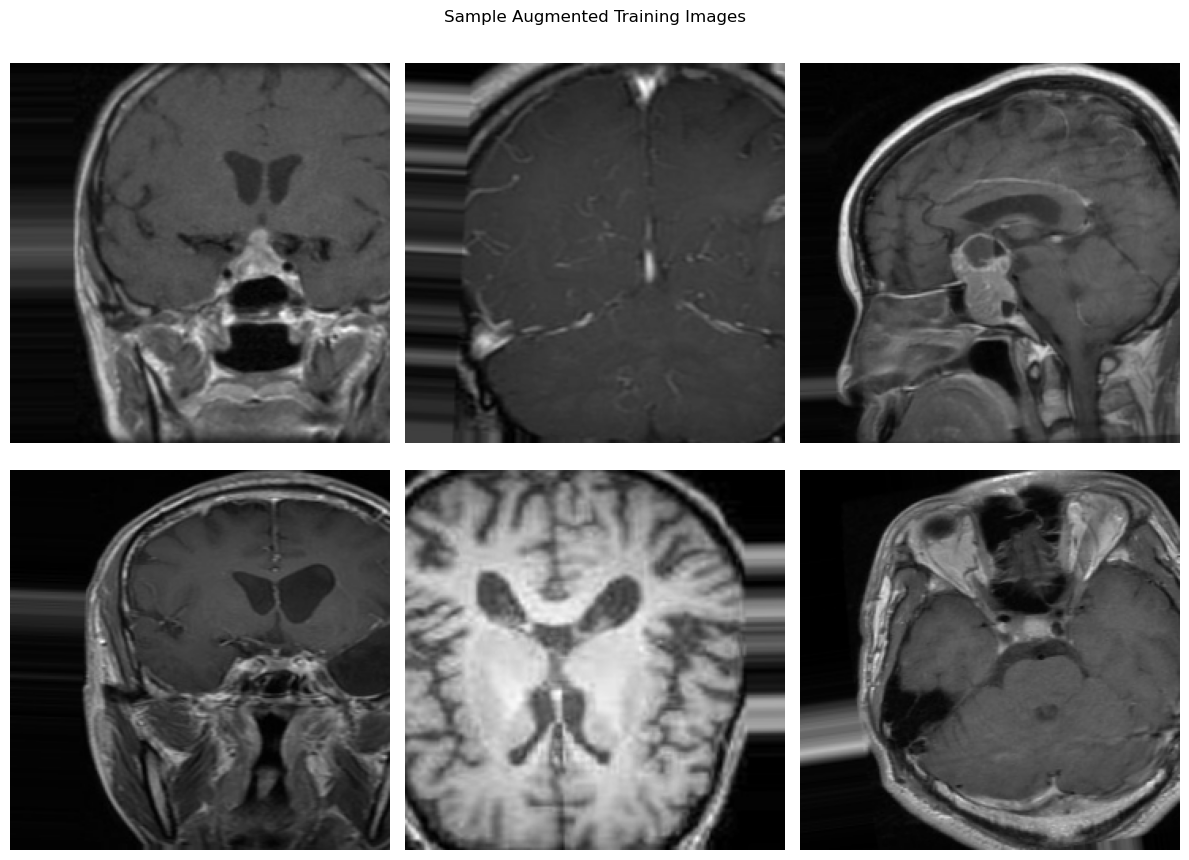

In [9]:
sample_x, sample_y = next(train_data)

plt.figure(figsize=(12, 9))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(array_to_img(sample_x[i]))
    plt.axis("off")
plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()


## Model Architecture - EfficientNetB1

In [10]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalMaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

effenet = EfficientNetB1(weights="imagenet", include_top=False, input_shape=(240, 240, 3))

# Freeze layer awal, fine-tune layer akhir
# Unfreeze lebih banyak
for layer in effenet.layers[:-50]:
    layer.trainable = False
for layer in effenet.layers[-50:]:
    layer.trainable = True

x = effenet.output
x = GlobalMaxPooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(4, activation="softmax")(x)

model = Model(inputs=effenet.input, outputs=x)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 240, 240, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 240, 240, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 240, 240, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 240, 240, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 241, 241, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 120, 120, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 120, 120, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 120, 120, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 120, 120, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 120, 120, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 120, 120, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 6,910,347 (26.36 MB)

 Trainable params: 3,834,548 (14.63 MB)

 Non-trainable params: 3,075,799 (11.73 MB)

## Compile & Callbacks

In [11]:
model_save_path = os.path.join(save_dir, "modelf.h5")

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint = ModelCheckpoint(model_save_path, monitor="val_accuracy", save_best_only=True, mode="auto", verbose=1)
earlystop  = EarlyStopping(monitor="val_accuracy", patience=7, mode="auto", verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor="val_accuracy", factor=0.2, patience=3, min_delta=0.001, mode="auto", verbose=1)


## Training

In [12]:
history = model.fit(
    train_data, epochs=30, validation_data=valid_data,
    verbose=1, callbacks=[checkpoint, earlystop, reduce_lr]
)


Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5253 - loss: 1.3060  
Epoch 1: val_accuracy improved from None to 0.85268, saving model to C:\Users\LENOVO\Downloads\research\modelf.h5



Epoch 1: finished saving model to C:\Users\LENOVO\Downloads\research\modelf.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 467s 3s/step - accuracy: 0.6500 - loss: 0.9558 - val_accuracy: 0.8527 - val_loss: 0.3628 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8268 - loss: 0.5136  
Epoch 2: val_accuracy improved from 0.85268 to 0.91518, saving model to C:\Users\LENOVO\Downloads\research\modelf.h5



Epoch 2: finished saving model to C:\Users\LENOVO\Downloads\research\modelf.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.8326 - loss: 0.4773 - val_accuracy: 0.9152 - val_loss: 0.2479 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8686 - loss: 0.3457  
Epoch 3: val_accuracy improved from 0.91518 to 0.92946, saving model to C:\Users\LENOVO\Downloads\research\modelf.h5



Epoch 3: finished saving model to C:\Users\LENOVO\Downloads\research\modelf.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 374s 3s/step - accuracy: 0.8696 - loss: 0.3519 - val_accuracy: 0.9295 - val_loss: 0.2078 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8912 - loss: 0.2956  
Epoch 4: val_accuracy improved from 0.92946 to 0.96339, saving model to C:\Users\LENOVO\Downloads\research\modelf.h5



Epoch 4: finished saving model to C:\Users\LENOVO\Downloads\research\modelf.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 381s 3s/step - accuracy: 0.8877 - loss: 0.2962 - val_accuracy: 0.9634 - val_loss: 0.1214 - learning_rate: 1.0000e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9193 - loss: 0.2259  
Epoch 5: val_accuracy did not improve from 0.96339
140/140 ━━━━━━━━━━━━━━━━━━━━ 362s 3s/step - accuracy: 0.9112 - loss: 0.2377 - val_accuracy: 0.9625 - val_loss: 0.1128 - learning_rate: 1.0000e-04
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9174 - loss: 0.2091  
Epoch 6: val_accuracy improved from 0.96339 to 0.96607, saving model to C:\Users\LENOVO\Downloads\research\modelf.h5



Epoch 6: finished saving model to C:\Users\LENOVO\Downloads\research\modelf.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 359s 3s/step - accuracy: 0.9201 - loss: 0.2031 - val_accuracy: 0.9661 - val_loss: 0.0901 - learning_rate: 1.0000e-04
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9470 - loss: 0.1614  
Epoch 7: val_accuracy improved from 0.96607 to 0.97946, saving model to C:\Users\LENOVO\Downloads\research\modelf.h5



Epoch 7: finished saving model to C:\Users\LENOVO\Downloads\research\modelf.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.9424 - loss: 0.1684 - val_accuracy: 0.9795 - val_loss: 0.0673 - learning_rate: 1.0000e-04
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9455 - loss: 0.1564  
Epoch 8: val_accuracy did not improve from 0.97946
140/140 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.9482 - loss: 0.1488 - val_accuracy: 0.9696 - val_loss: 0.0763 - learning_rate: 1.0000e-04
Epoch 9/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9581 - loss: 0.1192  
Epoch 9: val_accuracy improved from 0.97946 to 0.98214, saving model to C:\Users\LENOVO\Downloads\research\modelf.h5



Epoch 9: finished saving model to C:\Users\LENOVO\Downloads\research\modelf.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.9580 - loss: 0.1198 - val_accuracy: 0.9821 - val_loss: 0.0592 - learning_rate: 1.0000e-04
Epoch 10/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9562 - loss: 0.1263  
Epoch 10: val_accuracy did not improve from 0.98214
140/140 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.9565 - loss: 0.1173 - val_accuracy: 0.9750 - val_loss: 0.0661 - learning_rate: 1.0000e-04
Epoch 11/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9582 - loss: 0.1141  
Epoch 11: val_accuracy did not improve from 0.98214
140/140 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.9583 - loss: 0.1140 - val_accuracy: 0.9723 - val_loss: 0.0683 - learning_rate: 1.0000e-04
Epoch 12/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9587 - loss: 0.1180  
Epoch 12: val_accuracy did not improve from 0.98214

Epoch 12: ReduceLROnPlateau reducing learning rate to 1.99999

## Training Graphs

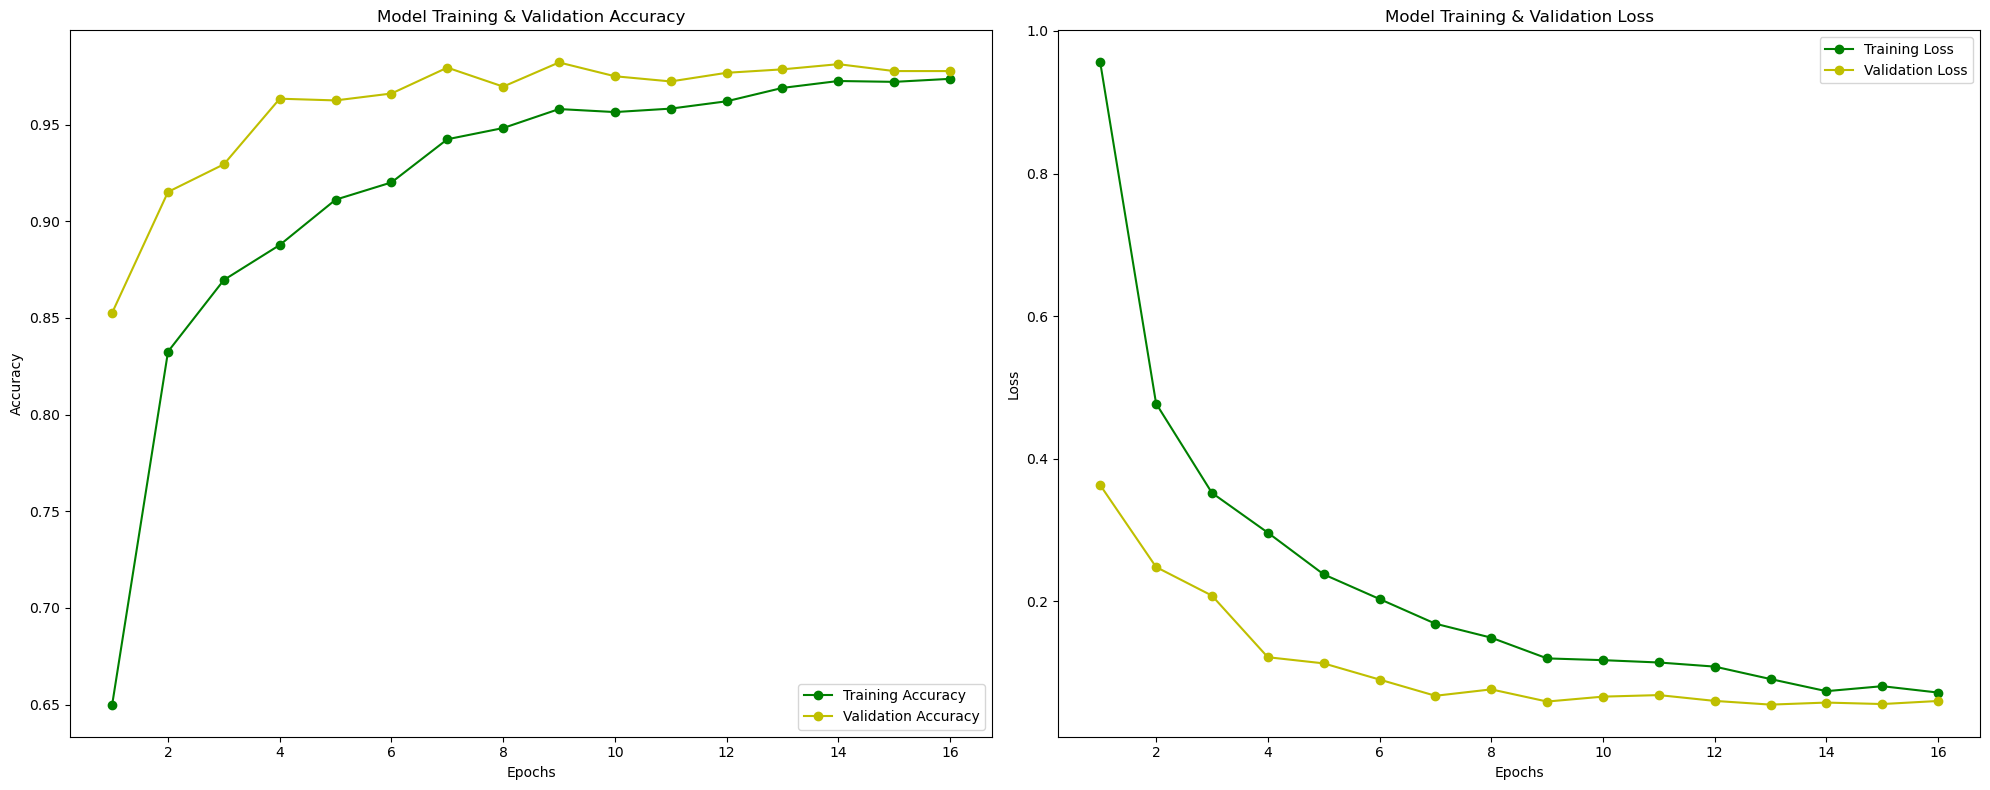

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

train_acc  = history.history["accuracy"]
train_loss = history.history["loss"]
val_acc    = history.history["val_accuracy"]
val_loss   = history.history["val_loss"]
epochs     = range(1, len(train_acc) + 1)

ax[0].plot(epochs, train_acc,  "g-o", label="Training Accuracy")
ax[0].plot(epochs, val_acc,    "y-o", label="Validation Accuracy")
ax[0].set_title("Model Training & Validation Accuracy")
ax[0].legend(loc="lower right")
ax[0].set_xlabel("Epochs"); ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs, train_loss, "g-o", label="Training Loss")
ax[1].plot(epochs, val_loss,   "y-o", label="Validation Loss")
ax[1].set_title("Model Training & Validation Loss")
ax[1].legend()
ax[1].set_xlabel("Epochs"); ax[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()


## Evaluation

In [14]:
print("Train Evaluation:")
model.evaluate(train_data)

print("\nTest Evaluation:")
model.evaluate(test_data)


Train Evaluation:
140/140 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9973 - loss: 0.0112

Test Evaluation:
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9525 - loss: 0.2435


[0.24350927770137787, 0.9524999856948853]

50/50 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step   


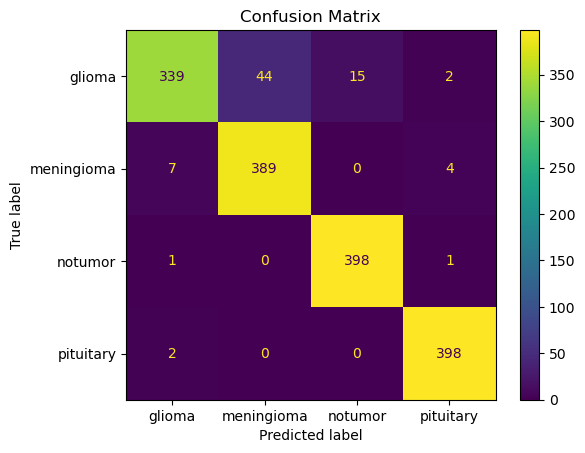

              precision    recall  f1-score   support

      glioma       0.97      0.85      0.91       400
  meningioma       0.90      0.97      0.93       400
     notumor       0.96      0.99      0.98       400
   pituitary       0.98      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, classification_report

y_test     = test_data.classes
y_test_hat = np.argmax(model.predict(test_data), axis=1)

cm = confusion_matrix(y_test, y_test_hat)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["glioma", "meningioma", "notumor", "pituitary"]
)
cm_display.plot()
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_test_hat,
      target_names=["glioma", "meningioma", "notumor", "pituitary"]))


## Prediction Visualization

Accuracy: 0.9525


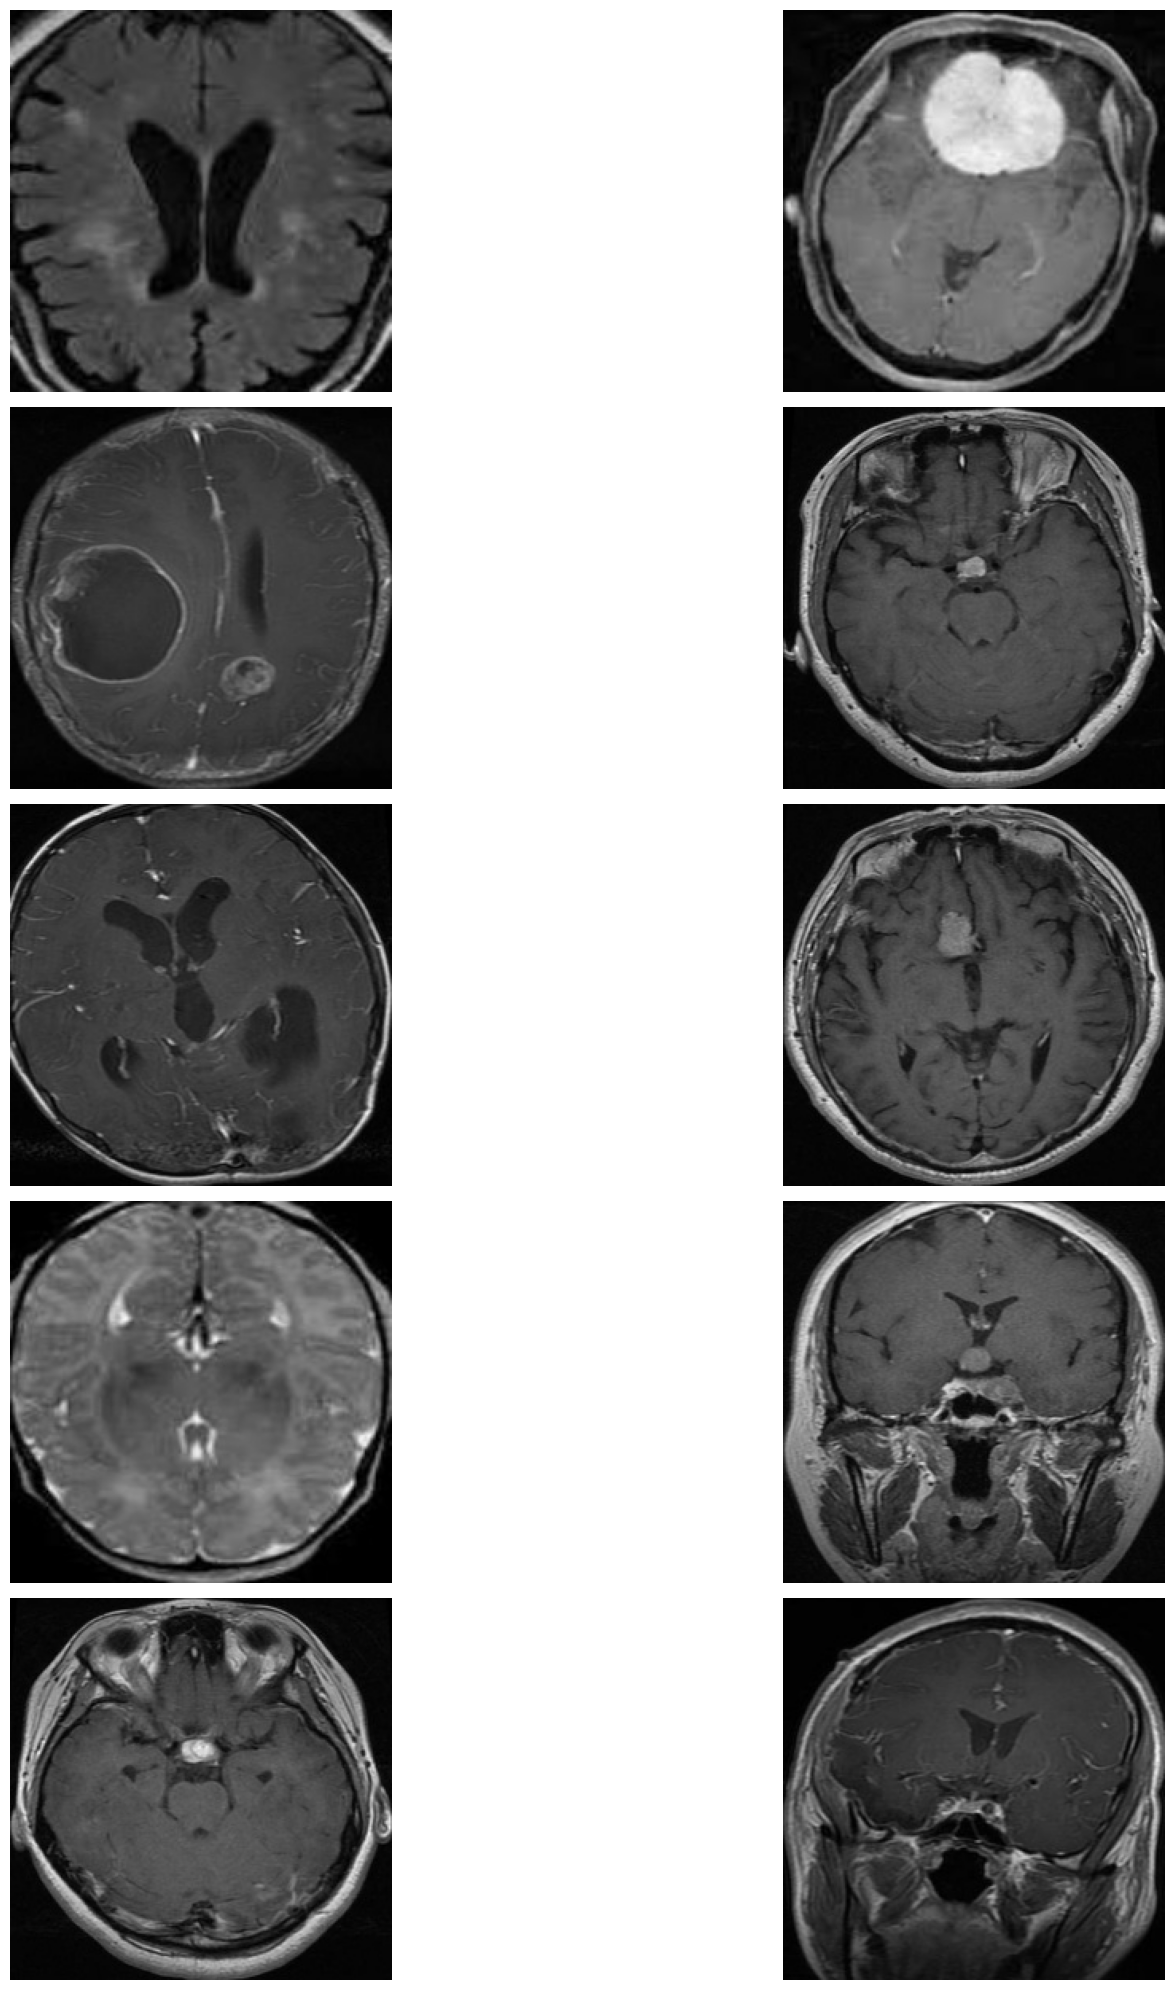

In [16]:
CLASS_DICT = {0: "glioma", 1: "meningioma", 2: "notumor", 3: "pituitary"}

images     = []
prediction = []
original   = []

for cls in os.listdir(crop_test_dir):
    cls_path = os.path.join(crop_test_dir, cls)
    if not os.path.isdir(cls_path): continue
    for item in os.listdir(cls_path):
        img = PIL.Image.open(os.path.join(cls_path, item)).resize((240, 240))
        images.append(img)
        img_arr = np.expand_dims(np.array(img), axis=0)
        pred    = CLASS_DICT[np.argmax(model.predict(img_arr, verbose=0))]
        prediction.append(pred)
        original.append(cls)

print(f"Accuracy: {accuracy_score(original, prediction):.4f}")

fig = plt.figure(figsize=(20, 20))
for i in range(10):
    j = random.randint(0, len(images) - 1)
    fig.add_subplot(5, 2, i+1)
    plt.xlabel(f"Prediction: {prediction[j]}   |   Original: {original[j]}")
    plt.imshow(images[j])
    plt.axis("off")
fig.tight_layout()
plt.show()


## GradCAM Visualization

In [17]:
import tensorflow.keras as K

def VizGradCAM(model, image, interpolant=0.5, plot_results=True):
    assert 0 < interpolant < 1, "Heatmap Interpolation Must Be Between 0 - 1"

    last_conv_layer = next(x for x in model.layers[::-1] if isinstance(x, K.layers.Conv2D))
    target_layer    = model.get_layer(last_conv_layer.name)

    original_img   = image
    img            = np.expand_dims(original_img, axis=0)
    prediction     = model.predict(img, verbose=0)
    prediction_idx = np.argmax(prediction)

    with tf.GradientTape() as tape:
        gradient_model = Model([model.inputs], [target_layer.output, model.output])
        conv2d_out, prediction = gradient_model(img)
        loss = prediction[:, prediction_idx]

    gradients      = tape.gradient(loss, conv2d_out)
    output         = conv2d_out[0]
    weights        = tf.reduce_mean(gradients[0], axis=(0, 1))

    activation_map = np.zeros(output.shape[0:2], dtype=np.float32)
    for idx, weight in enumerate(weights):
        activation_map += weight * output[:, :, idx]

    activation_map = cv2.resize(activation_map.numpy(), (original_img.shape[1], original_img.shape[0]))
    activation_map = np.maximum(activation_map, 0)
    activation_map = (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min() + 1e-8)
    activation_map = np.uint8(255 * activation_map)

    heatmap     = cv2.applyColorMap(activation_map, cv2.COLORMAP_JET)
    original_u8 = np.uint8((original_img - original_img.min()) / (original_img.max() - original_img.min() + 1e-8) * 255)
    cvt_heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    plt.rcParams["figure.dpi"] = 100
    if plot_results:
        plt.imshow(np.uint8(original_u8 * interpolant + cvt_heatmap * (1 - interpolant)))
        plt.axis("off")
        plt.title(f"GradCAM - Predicted: {CLASS_DICT[prediction_idx]}")
        plt.show()
    else:
        return cvt_heatmap


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 240, 240, 3))
  warnings.warn(msg)


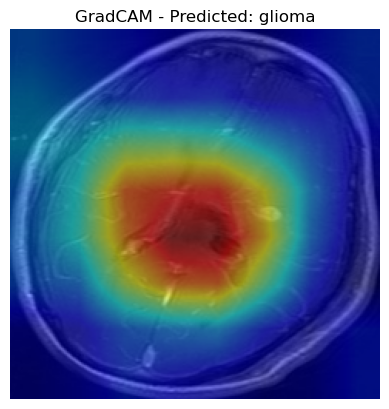

In [18]:
test_img_path = os.path.join(crop_test_dir, "glioma", "1.jpg")
test_img = cv2.imread(test_img_path)
VizGradCAM(model, img_to_array(test_img), plot_results=True)
